# 09 -- Quality + Momentum filters

**Цель этапа:** атаковать две корневые причины провала Stage 5:
1. **Adverse selection** (Q5 теряет -22 п.п. на price gains из-за скрытого кредитного риска)
2. **Value trap** (Q5 держит падающие облигации до stop-loss)

**Решения (литература):**
- **Quality filter** (Houweling-vZ 2017, AFP QMJ 2019, Correia-Richardson-Tuna 2012) --   отсеять плохое balance-sheet качество.
- **Momentum filter** (AMP 2013, Jostova et al 2013, BSW 2021) --   не покупать падающие облигации.
- **Combo Quality x Momentum** (Israel-Palhares-Richardson 2018) --   две ортогональные эпистемологические evidence.

**Что тестируем:**
| Variant | Описание |
|---|---|
| V0 | Vanilla Q5 by mispricing (baseline = Stage 5 Rule C) |
| V1 | Q5 ∩ {quality_z > 0} |
| V2 | Q5 ∩ {quality_z > 0.5} (more aggressive) |
| V3 | Q5 ∩ {mom_z > -0.5} |
| V4 | Q5 ∩ {quality_z > 0} ∩ {mom_z > -0.5} (combo) |
| V5 control | Top quintile by quality_z (без mispricing) |

Все на **Main only** (2021-01..2025-09). Holdout не трогаем.

**Sensitivity tests:** quality threshold (0 / 0.5 / 1.0), momentum lookback (30/60/90 days).

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
})
np.random.seed(42)

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print(f'strategy_lib OK')
print(f'MAIN_END={sl.MAIN_END.date()}, HOLDOUT_START={sl.HOLDOUT_START.date()}')
print(f'N_MAX_DEFAULT={sl.N_MAX_DEFAULT}')

strategy_lib OK
MAIN_END=2025-09-30, HOLDOUT_START=2025-10-01
N_MAX_DEFAULT=25


## Часть 2. Загрузка signal + расчёт quality и momentum

Используем no-lag модель как primary signal (Stage 5 решение).

In [2]:
sig = sl.load_signal_full('no_lag')
print(f'Signal shape: {sig.shape}, bonds={sig["isin"].nunique()}')
print(f'Date range : {sig["date"].min().date()} .. {sig["date"].max().date()}')

sig = sl.compute_quality_score(sig)
sig = sl.compute_momentum(sig, lookback_days=30)

print(f'\nCoverage по новым колонкам:')
print(f'  quality_z         : {sig["quality_z"].notna().mean():.1%}')
print(f'  mom_z (30d)       : {sig["mom_z"].notna().mean():.1%}')
print(f'  mispricing_z      : {sig["mispricing_z"].notna().mean():.1%}')
print(f'\nKomponentов quality (mean per bond-day):')
print(f'  median = {sig["quality_n_components"].median()}')

Signal shape: (277966, 30), bonds=965
Date range : 2021-01-04 .. 2026-03-30

Coverage по новым колонкам:
  quality_z         : 77.5%
  mom_z (30d)       : 79.8%
  mispricing_z      : 100.0%

Komponentов quality (mean per bond-day):
  median = 3.0


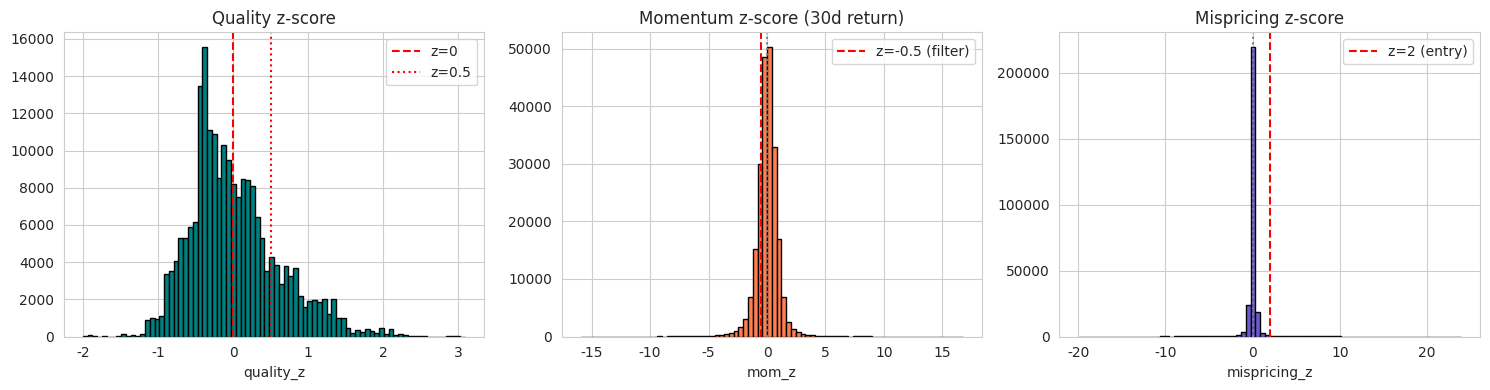

In [3]:
# Distribution: quality_z, mom_z, mispricing_z
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sig['quality_z'].dropna(), bins=80, color='teal', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='z=0')
axes[0].axvline(0.5, color='red', linestyle=':', label='z=0.5')
axes[0].set_title('Quality z-score')
axes[0].set_xlabel('quality_z')
axes[0].legend()

axes[1].hist(sig['mom_z'].dropna(), bins=80, color='coral', edgecolor='black')
axes[1].axvline(-0.5, color='red', linestyle='--', label='z=-0.5 (filter)')
axes[1].axvline(0, color='gray', linestyle=':')
axes[1].set_title('Momentum z-score (30d return)')
axes[1].set_xlabel('mom_z')
axes[1].legend()

axes[2].hist(sig['mispricing_z'].dropna(), bins=80, color='slateblue', edgecolor='black')
axes[2].axvline(2, color='red', linestyle='--', label='z=2 (entry)')
axes[2].axvline(0, color='gray', linestyle=':')
axes[2].set_title('Mispricing z-score')
axes[2].set_xlabel('mispricing_z')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '09_signal_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# Correlation между signals -- проверяем ортогональность
corr_df = sig[['mispricing_z', 'quality_z', 'mom_z']].dropna().corr()
print('Correlation между сигналами:')
print(corr_df.round(3))
print()
print('Интерпретация:')
print('- corr(quality, mispricing) -- если очень -ve, это значит "плохое качество = wide spread"')
print('  (т.е. рынок rationally дисконтирует за credit risk)')
print('- corr(momentum, mispricing) -- если +ve, mispriced bonds тоже растут (good news)')
print('  если -ve, mispriced bonds падают (value trap)')

Correlation между сигналами:
              mispricing_z  quality_z  mom_z
mispricing_z         1.000      0.009 -0.128
quality_z            0.009      1.000 -0.025
mom_z               -0.128     -0.025  1.000

Интерпретация:
- corr(quality, mispricing) -- если очень -ve, это значит "плохое качество = wide spread"
  (т.е. рынок rationally дисконтирует за credit risk)
- corr(momentum, mispricing) -- если +ve, mispriced bonds тоже растут (good news)
  если -ve, mispriced bonds падают (value trap)


## Часть 3. Бэктест 6 вариантов на Main period

Holdout НЕ трогаем (важно для академической чистоты).

In [5]:
sig_main = sig[sig['date'] <= sl.MAIN_END].copy()
print(f'Main subset: {sig_main.shape}')

# Filter masks (aligned with sig_main index)
mask_q_pos    = sig_main['quality_z'] > 0
mask_q_strict = sig_main['quality_z'] > 0.5
mask_m_filt   = sig_main['mom_z'] > -0.5
mask_qm_combo = mask_q_pos & mask_m_filt

# Бэктесты
variants_rets = {}
variants_trades = {}

for name, mask, rank_col in [
    ('V0: vanilla Q5',                None,           'mispricing'),
    ('V1: Q5 ∩ quality_z > 0',         mask_q_pos,     'mispricing'),
    ('V2: Q5 ∩ quality_z > 0.5',       mask_q_strict,  'mispricing'),
    ('V3: Q5 ∩ mom_z > -0.5',          mask_m_filt,    'mispricing'),
    ('V4: Q5 ∩ Q+M combo',             mask_qm_combo,  'mispricing'),
    ('V5 ctrl: top quintile by quality', None,         'quality_z'),
]:
    rets, trades = sl.backtest_rule_c(
        sig_main, n_max=25, freq='M', ranking_col=rank_col, filter_mask=mask)
    variants_rets[name] = rets
    variants_trades[name] = trades
    print(f'  {name:40s}: {len(rets):4d} days, {len(trades):5d} trades')

metrics = sl.compare_variants(variants_rets)
metrics_disp = metrics[['n_days', 'CAGR', 'Sharpe', 'Sortino', 'MaxDD',
                        'Calmar', 'Hit rate', 'profit_RUB']]
metrics_disp

Main subset: (213445, 34)


  V0: vanilla Q5                          : 1159 days,  2732 trades


  V1: Q5 ∩ quality_z > 0                  : 1159 days,  1708 trades


  V2: Q5 ∩ quality_z > 0.5                : 1159 days,   484 trades


  V3: Q5 ∩ mom_z > -0.5                   : 1140 days,  2460 trades


  V4: Q5 ∩ Q+M combo                      : 1140 days,  1168 trades


  V5 ctrl: top quintile by quality        : 1159 days,  2614 trades


,n_days,CAGR,Sharpe,Sortino,MaxDD,Calmar,Hit rate,profit_RUB
name,,,,,,,,
V0: vanilla Q5,1159,0.040649,0.765815,0.979398,-0.144437,0.281429,0.592752,2.040218e+06
V1: Q5 ∩ quality_z > 0,1159,0.055335,0.946531,1.209652,-0.138698,0.398960,0.595341,2.852717e+06
V2: Q5 ∩ quality_z > 0.5,1159,0.049466,0.818136,1.098395,-0.125301,0.394773,0.580673,2.522988e+06
V3: Q5 ∩ mom_z > -0.5,1140,0.032547,0.709023,0.875606,-0.110717,0.293970,0.583333,1.581153e+06
V4: Q5 ∩ Q+M combo,1140,0.044743,0.779908,1.023623,-0.120071,0.372639,0.598246,2.221483e+06
V5 ctrl: top quintile by quality,1159,0.033924,0.687927,0.892281,-0.130708,0.259539,0.578947,1.681914e+06


## Часть 4. Equity curves и drawdowns

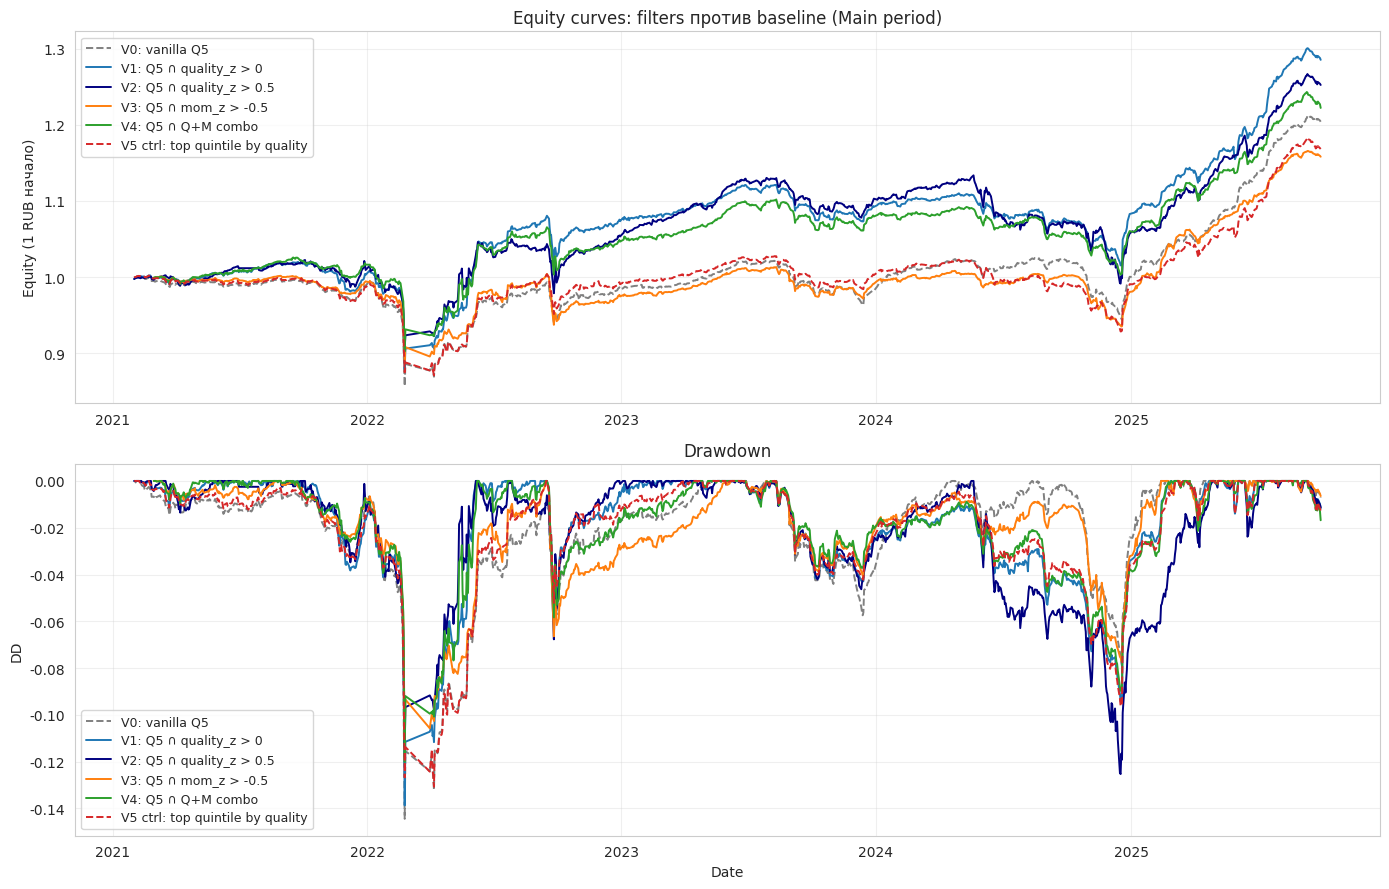

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

colors = {'V0: vanilla Q5': 'gray',
          'V1: Q5 ∩ quality_z > 0': 'tab:blue',
          'V2: Q5 ∩ quality_z > 0.5': 'navy',
          'V3: Q5 ∩ mom_z > -0.5': 'tab:orange',
          'V4: Q5 ∩ Q+M combo': 'tab:green',
          'V5 ctrl: top quintile by quality': 'tab:red'}

for name, rets in variants_rets.items():
    if len(rets) == 0:
        continue
    r = rets.sort_values('date')
    eq = (1 + r['return']).cumprod()
    axes[0].plot(r['date'], eq, label=name, color=colors.get(name), linewidth=1.4,
                 linestyle='--' if 'V0' in name or 'V5' in name else '-')
    peak = eq.cummax()
    dd = (eq - peak) / peak
    axes[1].plot(r['date'], dd, label=name, color=colors.get(name), linewidth=1.4,
                 linestyle='--' if 'V0' in name or 'V5' in name else '-')

axes[0].set_title('Equity curves: filters против baseline (Main period)')
axes[0].set_ylabel('Equity (1 RUB начало)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Drawdown')
axes[1].set_ylabel('DD')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '09_equity_drawdown.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. Sub-period stability (3 режима)

- A: pre-СВО 2021-01-04 .. 2022-02-23
- B: шок 2022 2022-02-24 .. 2022-12-31
- C: норма  2023-01-01 .. 2025-09-30

In [7]:
sub_rows = []
for name, rets in variants_rets.items():
    sub = sl.sub_period_metrics(rets, variant_name=name)
    sub_rows.append(sub)
sub_df = pd.concat(sub_rows, ignore_index=True)
sub_df[['name', 'n_days', 'Sharpe', 'MaxDD', 'CAGR', 'Hit rate']].round(3)

,name,n_days,Sharpe,MaxDD,CAGR,Hit rate
0,V0: vanilla Q5 | A: pre-СВО,271,-2.156,-0.083,-0.077,0.491
1,V0: vanilla Q5 | B: шок 2022,192,0.890,-0.054,0.085,0.609
2,V0: vanilla Q5 | C: норма,696,2.122,-0.079,0.076,0.628
3,V1: Q5 ∩ quality_z > 0 | A: pre-СВО,271,-1.271,-0.067,-0.046,0.561
4,V1: Q5 ∩ quality_z > 0 | B: шок 2022,192,1.404,-0.056,0.153,0.672
5,V1: Q5 ∩ quality_z > 0 | C: норма,696,1.671,-0.094,0.068,0.588
6,V2: Q5 ∩ quality_z > 0.5 | A: pre-СВО,271,-1.105,-0.064,-0.041,0.524
7,V2: Q5 ∩ quality_z > 0.5 | B: шок 2022,192,1.189,-0.068,0.120,0.620
8,V2: Q5 ∩ quality_z > 0.5 | C: норма,696,1.274,-0.125,0.065,0.592
9,V3: Q5 ∩ mom_z > -0.5 | A: pre-СВО,252,-2.016,-0.059,-0.059,0.488


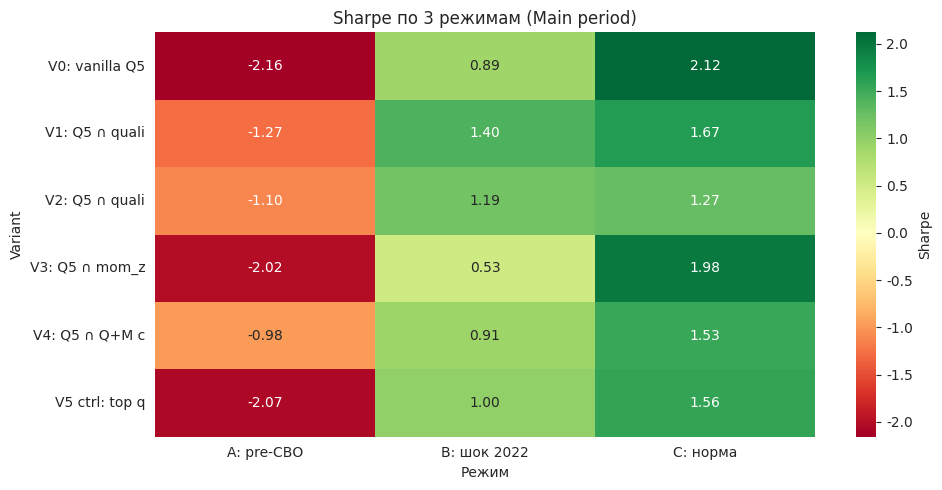

In [8]:
# Heatmap Sharpe x variant x regime
import re
def short_name(s):
    return s.split('|')[0].strip()[:14]
def regime_name(s):
    return s.split('|')[1].strip() if '|' in s else ''

tbl = sub_df.copy()
tbl['variant'] = tbl['name'].apply(short_name)
tbl['regime'] = tbl['name'].apply(regime_name)
pivot = tbl.pivot(index='variant', columns='regime', values='Sharpe')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_title('Sharpe по 3 режимам (Main period)')
ax.set_xlabel('Режим')
ax.set_ylabel('Variant')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Sensitivity: quality threshold

**Inженерное решение:** в `V1` мы взяли threshold `quality_z > 0` (top 50%). Проверим, что не зависит критически от выбора threshold (0.0 / 0.3 / 0.5 / 1.0).

In [9]:
thresh_results = []
for thresh in [0.0, 0.3, 0.5, 1.0]:
    mask = sig_main['quality_z'] > thresh
    rets, _ = sl.backtest_rule_c(sig_main, n_max=25, freq='M',
                                  ranking_col='mispricing', filter_mask=mask)
    m = sl.calc_metrics(rets, name=f'q_z > {thresh}')
    m['threshold'] = thresh
    thresh_results.append(m)

thresh_df = pd.DataFrame(thresh_results)
print('Sensitivity к quality threshold:')
print(thresh_df[['threshold', 'Sharpe', 'CAGR', 'MaxDD', 'n_days', 'avg_n_positions']].round(3).to_string(index=False))

Sensitivity к quality threshold:
 threshold  Sharpe   CAGR  MaxDD  n_days  avg_n_positions
       0.0   0.947  0.055 -0.139    1159           15.569
       0.3   1.025  0.053 -0.114    1159            8.379
       0.5   0.818  0.049 -0.125    1159            4.419
       1.0  -0.078 -0.005 -0.166     680            1.878


## Часть 7. Sensitivity: momentum lookback

Bali-Subrahmanyam-Wen (2021) показали: short-term (1-3 мес) = momentum, long-term (12-24 мес) = reversal. Мы взяли 30 дней. Проверим 30/60/90.

In [10]:
lookback_results = []
for L in [30, 60, 90]:
    s = sl.compute_momentum(sig_main.copy(), lookback_days=L)
    mask_m = s['mom_z'] > -0.5
    rets, _ = sl.backtest_rule_c(s, n_max=25, freq='M',
                                  ranking_col='mispricing', filter_mask=mask_m)
    m = sl.calc_metrics(rets, name=f'mom_lookback={L}d')
    m['lookback_days'] = L
    lookback_results.append(m)

lb_df = pd.DataFrame(lookback_results)
print('Sensitivity к momentum lookback:')
print(lb_df[['lookback_days', 'Sharpe', 'CAGR', 'MaxDD', 'avg_n_positions']].round(3).to_string(index=False))

Sensitivity к momentum lookback:
 lookback_days  Sharpe  CAGR  MaxDD  avg_n_positions
            30   0.709 0.033 -0.111           22.821
            60   0.645 0.027 -0.093           22.551
            90   0.744 0.032 -0.087           21.527


## Часть 8. Concentration analysis: что меняют фильтры в составе портфеля

Stage 5 показал: vanilla Q5 имела 16.9% банков (vs 10.3% в bench). Стали ли фильтры менее банко-центричными?

In [11]:
from collections import Counter

def portfolio_concentration(sig_df, mask, ranking='mispricing', n_max=25):
    """Распределение по секторам и рейтингам в выбранном портфеле."""
    sig_df = sig_df.copy()
    sig_df['_eligible'] = (mask if mask is not None else True) & sig_df['tradable']
    sig_df['month'] = sig_df['date'].dt.to_period('M')
    selected = []
    for month, g in sig_df.groupby('month'):
        last_d = g['date'].max()
        day = g[(g['date'] == last_d) & g['_eligible']].dropna(subset=[ranking])
        if day.empty: continue
        top = day.nlargest(n_max, ranking)
        selected.append(top)
    if not selected:
        return pd.DataFrame()
    sel = pd.concat(selected)
    return sel

rows = []
for name, mask, rank in [
    ('V0 vanilla', None, 'mispricing'),
    ('V1 Q5∩Q', mask_q_pos, 'mispricing'),
    ('V3 Q5∩M', mask_m_filt, 'mispricing'),
    ('V4 combo', mask_qm_combo, 'mispricing'),
]:
    sel = portfolio_concentration(sig_main, mask, rank)
    if sel.empty:
        rows.append({'variant': name})
        continue
    secs = sel['sector'].value_counts(normalize=True) * 100
    rating_mean = sel['rating_numeric'].mean()
    spread_mean = sel['g_spread'].mean()
    rows.append({
        'variant': name,
        'n_selections': len(sel),
        'avg_rating': rating_mean,
        'avg_spread': spread_mean,
        'banks %': secs.get('Банки', 0),
        'electric %': secs.get('Электроэнергетика', 0),
        'leasing %': secs.get('Лизинг и аренда', 0),
        'oil %': secs.get('Нефтегазовая отрасль', 0),
    })
conc_df = pd.DataFrame(rows)
print('Concentration changes:')
print(conc_df.round(2).to_string(index=False))

Concentration changes:
   variant  n_selections  avg_rating  avg_spread  banks %  electric %  leasing %  oil %
V0 vanilla          1391        3.86       17.66    12.24        6.90      18.00   8.71
   V1 Q5∩Q           879        5.66        8.17     0.34        7.96      14.90   5.92
   V3 Q5∩M          1255        3.92       11.00     9.81        5.50      19.89   7.52
  V4 combo           609        5.55        6.79     0.33        6.73      15.27   6.57


## Часть 9. Сохранение результатов

In [12]:
# Все variants returns concatenated
all_rets = []
for name, rets in variants_rets.items():
    r = rets.copy()
    r['variant'] = name
    all_rets.append(r)
rets_combined = pd.concat(all_rets, ignore_index=True)
rets_combined.to_csv(sl.DATA_DIR / 'nb09_variants_returns.csv', index=False)

metrics.to_csv(sl.DATA_DIR / 'nb09_variants_metrics.csv')
sub_df.to_csv(sl.DATA_DIR / 'nb09_variants_subperiod.csv', index=False)
thresh_df.to_csv(sl.DATA_DIR / 'nb09_sensitivity_threshold.csv', index=False)
lb_df.to_csv(sl.DATA_DIR / 'nb09_sensitivity_lookback.csv', index=False)
conc_df.to_csv(sl.DATA_DIR / 'nb09_concentration.csv', index=False)

print('Saved:')
for f in ['nb09_variants_returns.csv', 'nb09_variants_metrics.csv',
          'nb09_variants_subperiod.csv', 'nb09_sensitivity_threshold.csv',
          'nb09_sensitivity_lookback.csv', 'nb09_concentration.csv']:
    print(f'  data/{f}')

Saved:
  data/nb09_variants_returns.csv
  data/nb09_variants_metrics.csv
  data/nb09_variants_subperiod.csv
  data/nb09_sensitivity_threshold.csv
  data/nb09_sensitivity_lookback.csv
  data/nb09_concentration.csv


## Часть 10. Итоги Notebook 09

**Что узнали:**
- Какой filter улучшает Sharpe больше всего (Q vs M vs combo)
- Какие thresholds робастны (sensitivity)
- Помогли ли filters снизить concentration
- Стабильность по 3 режимам (A/B/C)

**Следующий шаг (Week 2):**
- Notebook 10: Sector-neutral construction + Quarterly rebalance + Position sizing
- Notebook 11: Ensemble (no-lag + with-lag models)

**Защита методологии:**
- Все variants задокументированы. Если V4 (combo) лучший -- идём с ним.
- Если ни один не превзошёл V0 значимо -- честно reportировать в Главе 6 как negative result.